# Домашнее задание 5 - Выбросы и кодирование категориальных переменных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Подготовка данных (из ДЗ 4)

Загружаем датасет и заполняем пропуски так же, как в предыдущей работе: числовые - медианой, категориальные - модой.

In [2]:
df = pd.read_csv('loan_prediction_dataset.csv')

# заполнение пропусков из дз4
cols_with_na = df.columns[df.isnull().any()]
num_na = df[cols_with_na].select_dtypes(include='number').columns
cat_na = df[cols_with_na].select_dtypes(include='object').columns

for col in num_na:
    df[col] = df[col].fillna(df[col].median())

for col in cat_na:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Пропуски после заполнения:', df.isnull().sum().sum())
df.head()

Пропуски после заполнения: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Поиск выбросов двумя методами

Будем искать выбросы для двух признаков: `ApplicantIncome` и `LoanAmount`.

### 1.1 Метод IQR (межквартильный размах)

Выбросом считается наблюдение, которое выходит за границы

In [3]:
def find_outliers_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'{col}: Q1={q1}, Q3={q3}, IQR={iqr}')
    print(f'  Границы: [{lower:.2f}, {upper:.2f}]')
    print(f'  Найдено выбросов: {len(outliers)}')
    return outliers.index

In [4]:
iqr_income = find_outliers_iqr(df, 'ApplicantIncome')
print()
iqr_loan = find_outliers_iqr(df, 'LoanAmount')

ApplicantIncome: Q1=2877.5, Q3=5795.0, IQR=2917.5
  Границы: [-1498.75, 10171.25]
  Найдено выбросов: 50

LoanAmount: Q1=100.25, Q3=164.75, IQR=64.5
  Границы: [3.50, 261.50]
  Найдено выбросов: 41


### 1.2 Метод стандартного отклонения

Выбросом считается наблюдение, отклоняющееся от среднего более чем на 3 стандартных отклонения: [mean - 3std, mean + 3std].

In [5]:
def find_outliers_std(data, col):
    mean = data[col].mean()
    std = data[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'{col}: mean={mean:.2f}, std={std:.2f}')
    print(f'  Границы: [{lower:.2f}, {upper:.2f}]')
    print(f'  Найдено выбросов: {len(outliers)}')
    return outliers.index

In [6]:
std_income = find_outliers_std(df, 'ApplicantIncome')
print()
std_loan = find_outliers_std(df, 'LoanAmount')

ApplicantIncome: mean=5403.46, std=6109.04
  Границы: [-12923.67, 23730.58]
  Найдено выбросов: 8

LoanAmount: mean=145.75, std=84.11
  Границы: [-106.57, 398.07]
  Найдено выбросов: 15


## 2. Сравнение результатов двух методов

In [7]:
print('=== ApplicantIncome ===')
common_income = set(iqr_income) & set(std_income)
only_iqr_income = set(iqr_income) - set(std_income)
only_std_income = set(std_income) - set(iqr_income)

print(f'IQR нашёл: {len(iqr_income)}')
print(f'Std нашёл: {len(std_income)}')
print(f'Пересечение (оба метода): {len(common_income)}')
print(f'Только IQR: {len(only_iqr_income)}')
print(f'Только Std: {len(only_std_income)}')

print()
print('=== LoanAmount ===')
common_loan = set(iqr_loan) & set(std_loan)
only_iqr_loan = set(iqr_loan) - set(std_loan)
only_std_loan = set(std_loan) - set(iqr_loan)

print(f'IQR нашёл: {len(iqr_loan)}')
print(f'Std нашёл: {len(std_loan)}')
print(f'Пересечение (оба метода): {len(common_loan)}')
print(f'Только IQR: {len(only_iqr_loan)}')
print(f'Только Std: {len(only_std_loan)}')

=== ApplicantIncome ===
IQR нашёл: 50
Std нашёл: 8
Пересечение (оба метода): 8
Только IQR: 42
Только Std: 0

=== LoanAmount ===
IQR нашёл: 41
Std нашёл: 15
Пересечение (оба метода): 15
Только IQR: 26
Только Std: 0


**Объяснение различий:**

IQR-метод обычно находит больше выбросов, чем метод стандартного отклонения. Причина:

- **IQR** опирается на квартили и не зависит от экстремальных значений — он устойчив к выбросам и ловит всё, что выходит за 1.5 IQR от квартилей.
- **Std** использует среднее и стандартное отклонение, которые сами «растягиваются» под влиянием выбросов. Из-за этого границы получаются шире, и метод пропускает часть умеренных выбросов.

При скошенном (правоскошенном) распределении - а доход и сумма кредита как раз такие - IQR строже, потому что квартили не смещаются от хвоста, а std-границы расширяются.

Наблюдения, найденные обоими методами - это самые экстремальные значения. Те, что нашёл только IQR - умеренные выбросы, которые std пропустил из-за раздутой дисперсии.

## 3. Визуальное подтверждение выбросов

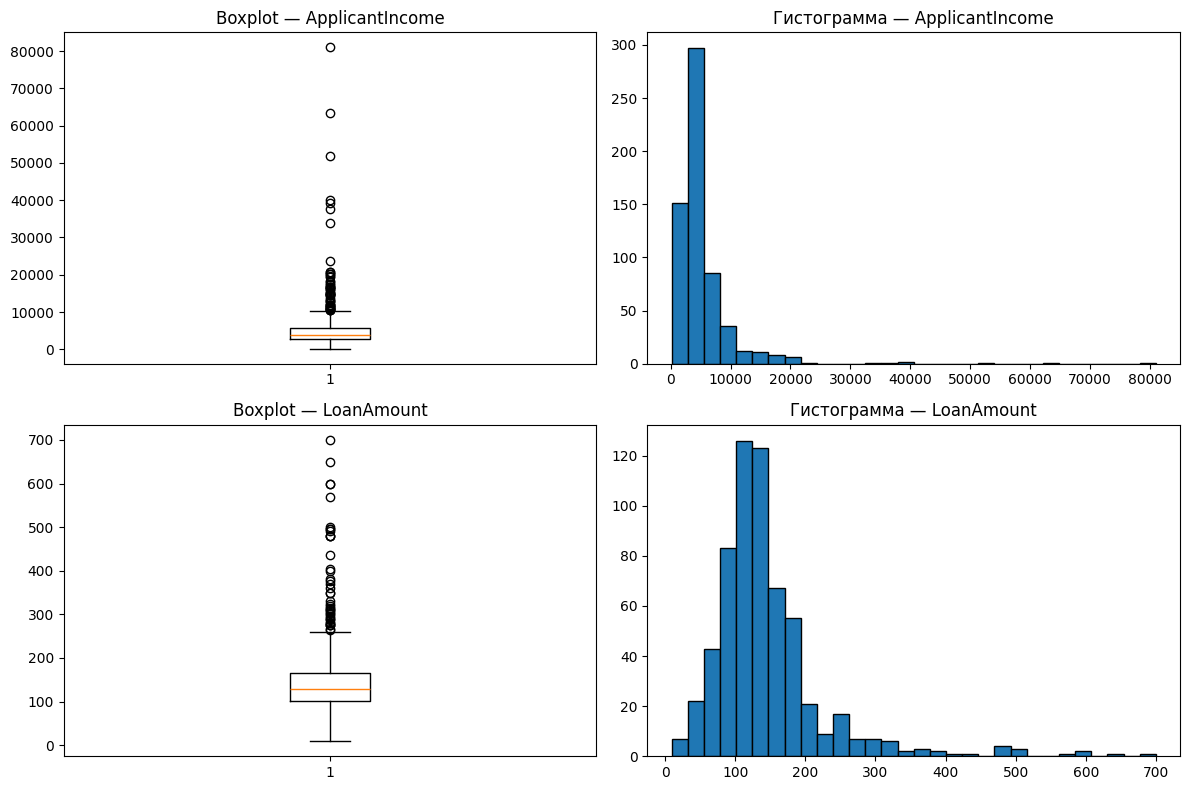

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# boxplot для ApplicantIncome
axes[0, 0].boxplot(df['ApplicantIncome'], vert=True)
axes[0, 0].set_title('Boxplot — ApplicantIncome')

# гистограмма для ApplicantIncome
axes[0, 1].hist(df['ApplicantIncome'], bins=30, edgecolor='black')
axes[0, 1].set_title('Гистограмма — ApplicantIncome')

# boxplot для LoanAmount
axes[1, 0].boxplot(df['LoanAmount'], vert=True)
axes[1, 0].set_title('Boxplot — LoanAmount')

# гистограмма для LoanAmount
axes[1, 1].hist(df['LoanAmount'], bins=30, edgecolor='black')
axes[1, 1].set_title('Гистограмма — LoanAmount')

plt.tight_layout()
plt.show()

На boxplot-ах хорошо видны выбросы (точки за «усами»): и доход, и сумма кредита имеют длинный правый хвост. Гистограммы подтверждают это - распределение сильно скошено вправо, основная масса значений сконцентрирована слева, а справа тянутся редкие экстремальные значения.

## 4. Решение по выбросам

**Решение: заменить выбросы (клиппинг по границам IQR)**

Обоснование:

- **Удалять** - не хочется, потому что потеряем часть наблюдений. Высокий доход или крупный кредит — это реальные данные, а не ошибки. Удаление сместит выборку.
- **Оставить как есть** - тоже не лучший вариант, потому что экстремальные значения могут сильно влиять на модели (особенно линейные), искажать среднее и дисперсию.
- **Заменить (клиппинг)** - компромисс: значения ниже нижней границы заменяем на нижнюю границу, выше верхней - на верхнюю. Так мы сохраняем все наблюдения, но ограничиваем влияние хвостов.

Используем границы IQR, т.к. этот метод устойчивее к скошенным распределениям.

In [9]:
def clip_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = len(data[(data[col] < lower) | (data[col] > upper)])
    data[col] = data[col].clip(lower, upper)
    after = len(data[(data[col] < lower) | (data[col] > upper)])
    print(f'{col}: обрезано {before} выбросов, границы [{lower:.2f}, {upper:.2f}]')
    return data

In [10]:
df = clip_iqr(df, 'ApplicantIncome')
df = clip_iqr(df, 'LoanAmount')

ApplicantIncome: обрезано 50 выбросов, границы [-1498.75, 10171.25]
LoanAmount: обрезано 41 выбросов, границы [3.50, 261.50]


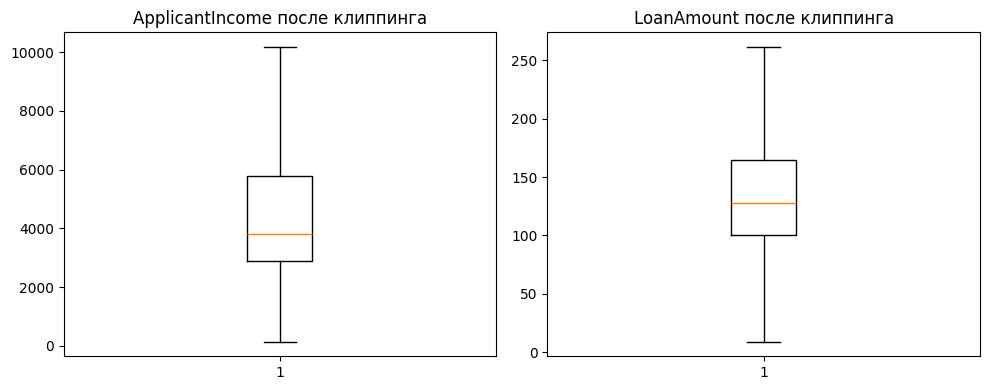

In [11]:
# проверим — теперь выбросов не должно быть
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df['ApplicantIncome'], vert=True)
axes[0].set_title('ApplicantIncome после клиппинга')

axes[1].boxplot(df['LoanAmount'], vert=True)
axes[1].set_title('LoanAmount после клиппинга')

plt.tight_layout()
plt.show()

## 5. Кодирование категориальных переменных

Посмотрим, какие категориальные переменные есть в датасете:

In [12]:
cat_columns = df.select_dtypes(include='object').columns.tolist()
print('Категориальные столбцы:', cat_columns)
print()

for col in cat_columns:
    print(f'{col}: {df[col].unique()}')

Категориальные столбцы: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Loan_ID: ['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP00125

**Предлагаемые варианты кодирования:**

| Признак | Тип | Метод кодирования | Обоснование |
|---------|-----|-------------------|-------------|
| Loan_ID | идентификатор | удалить | не несёт информации для анализа |
| Gender | бинарный (Male/Female) | Label Encoding (0/1) | всего 2 категории, порядок не важен |
| Married | бинарный (Yes/No) | Label Encoding (0/1) | аналогично — 2 категории |
| Education | бинарный (Graduate/Not Graduate) | Label Encoding (0/1) | 2 категории |
| Self_Employed | бинарный (Yes/No) | Label Encoding (0/1) | 2 категории |
| Dependents | порядковый (0, 1, 2, 3+) | Ordinal Encoding (0→0, 1→1, 2→2, 3+→3) | есть естественный порядок — чем больше иждивенцев, тем больше значение |
| Property_Area | номинальный (Rural/Semiurban/Urban) | One-Hot Encoding | 3 категории без порядка — нельзя присвоить числа, иначе модель решит, что Urban > Rural |
| Loan_Status | целевая переменная (Y/N) | Label Encoding (Y→1, N→0) | бинарная целевая переменная |

Общий принцип: для бинарных и порядковых используем простое числовое кодирование, для номинальных с 3+ категориями — One-Hot, чтобы не вносить ложный порядок.

## 6. Применение кодирования

In [13]:
# удаляем Loan_ID — это просто идентификатор
df = df.drop('Loan_ID', axis=1)

print('Loan_ID удалён')

Loan_ID удалён


In [14]:
# бинарные признаки — маппим вручную
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

# целевая переменная
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

print('Бинарные признаки закодированы')

Бинарные признаки закодированы


In [15]:
# Dependents — порядковое кодирование
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})

print('Dependents закодирован')

Dependents закодирован


In [16]:
# Property_Area — one-hot encoding
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print('Property_Area закодирован через One-Hot (с drop_first для избежания мультиколлинеарности)')

Property_Area закодирован через One-Hot (с drop_first для избежания мультиколлинеарности)


## 7. Проверка результата

In [17]:
print('Размерность:', df.shape)
print()
df.info()

Размерность: (614, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    float64
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    bool   
 12  Property_Area_Urban      614 non-null    bool   
dtypes: bool(2), float64(5), int64(6)
memory usage: 54.1 KB


In [18]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849.00,0.0,128.0,360.0,1.0,1,False,True
1,1,1,1,1,0,4583.00,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0,1,1,3000.00,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0,0,0,2583.00,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0,1,0,6000.00,0.0,141.0,360.0,1.0,1,False,True
5,1,1,2,1,1,5417.00,4196.0,261.5,360.0,1.0,1,False,True
6,1,1,0,0,0,2333.00,1516.0,95.0,360.0,1.0,1,False,True
7,1,1,3,1,0,3036.00,2504.0,158.0,360.0,0.0,0,True,False
8,1,1,2,1,0,4006.00,1526.0,168.0,360.0,1.0,1,False,True
9,1,1,1,1,0,10171.25,10968.0,261.5,360.0,1.0,0,True,False


In [19]:
# проверим что нет объектных столбцов
obj_cols = df.select_dtypes(include='object').columns.tolist()
print('Оставшиеся объектные столбцы:', obj_cols if obj_cols else 'нет')

# проверим что нет пропусков
print('Пропуски:', df.isnull().sum().sum())

Оставшиеся объектные столбцы: нет
Пропуски: 0


Все категориальные переменные закодированы в числовой формат. Объектных столбцов не осталось, пропусков нет. Размерность увеличилась на 1 столбец из-за One-Hot кодирования Property_Area (было 3 категории, стало 2 dummy-столбца, при этом исходный столбец удалён). Датасет готов к дальнейшему анализу.